In [1]:
import tensorflow as tf
import tf_keras as tf_keras
import tensorflow_hub as hub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorboard import notebook
from tf_keras.preprocessing.image import ImageDataGenerator
from tf_keras.models import Sequential, Model, save_model, load_model
from tf_keras.layers import Input, Conv2D, MaxPool2D, GlobalAveragePooling2D,BatchNormalization, Flatten, Dropout, Dense
from tf_keras.callbacks import Callback, ModelCheckpoint
from tf_keras.regularizers import l1_l2
from sklearn.compose import make_column_transformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os
import pathlib
import random
import datetime
import zipfile
import itertools
import shutil
from PIL import Image

In [3]:
downloadfile = "archive (2).zip"
zip_ref = zipfile.ZipFile(downloadfile)
zip_ref.extractall()
zip_ref.close()

In [2]:
!dir Vegetable_Images

 Volume in drive C is Acer
 Volume Serial Number is 3C62-C1A3

 Directory of C:\Users\hayat\T09Robotics and Intelegence System\3rd Term Projects\Vigetable\Vegetable_Images

04/20/2025  10:04 AM    <DIR>          .
04/20/2025  06:17 PM    <DIR>          ..
04/20/2025  10:04 AM    <DIR>          test
04/20/2025  10:04 AM    <DIR>          train
04/20/2025  10:04 AM    <DIR>          validation
               0 File(s)              0 bytes
               5 Dir(s)  134,203,314,176 bytes free


In [3]:
for dirpath, dirnames, filenames in os.walk('Vegetable_Images/'):
    print(f'directories: {len(dirnames)}\t images: {len(filenames)}\t path:{dirpath}')

directories: 3	 images: 0	 path:Vegetable_Images/
directories: 15	 images: 0	 path:Vegetable_Images/test
directories: 0	 images: 200	 path:Vegetable_Images/test\Bean
directories: 0	 images: 200	 path:Vegetable_Images/test\Bitter_Gourd
directories: 0	 images: 200	 path:Vegetable_Images/test\Bottle_Gourd
directories: 0	 images: 200	 path:Vegetable_Images/test\Brinjal
directories: 0	 images: 200	 path:Vegetable_Images/test\Broccoli
directories: 0	 images: 200	 path:Vegetable_Images/test\Cabbage
directories: 0	 images: 200	 path:Vegetable_Images/test\Capsicum
directories: 0	 images: 200	 path:Vegetable_Images/test\Carrot
directories: 0	 images: 200	 path:Vegetable_Images/test\Cauliflower
directories: 0	 images: 200	 path:Vegetable_Images/test\Cucumber
directories: 0	 images: 200	 path:Vegetable_Images/test\Papaya
directories: 0	 images: 200	 path:Vegetable_Images/test\Potato
directories: 0	 images: 200	 path:Vegetable_Images/test\Pumpkin
directories: 0	 images: 200	 path:Vegetable_Images/t

In [4]:
data_dir = pathlib.Path('Vegetable_Images/train/')
class_names = np.array([sorted(items.name for items in data_dir.glob("*"))])
print(class_names)

[['Bean' 'Bitter_Gourd' 'Bottle_Gourd' 'Brinjal' 'Broccoli' 'Cabbage'
  'Capsicum' 'Carrot' 'Cauliflower' 'Cucumber' 'Papaya' 'Potato'
  'Pumpkin' 'Radish' 'Tomato']]


In [5]:
classes = ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage',
          'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato',
          'Pumpkin', 'Radish', 'Tomato']

main_folder = 'Vegetable_Images'

for folder_type in ['train', 'test']:
    min_count = min([len(os.listdir(os.path.join(main_folder, folder_type, cls))) for cls in classes])
    
    for cls in classes:
        class_dir = os.path.join(main_folder, folder_type, cls)
        files = os.listdir(class_dir)
        
        if len(files) > min_count:
            random.shuffle(files)
            files_to_remove = files[min_count:]
            
            for file in files_to_remove:
                os.remove(os.path.join(class_dir, file))

In [6]:
# Image format checking and conversion
def check_images_format():
    all_jpg = True
    for subfolder in ['train', 'test']:
        for cls in classes:
            class_dir = os.path.join(main_folder, subfolder, cls)
            if not os.path.exists(class_dir):
                print(f"Warning: Directory not found - {class_dir}")
                continue
            for file in os.listdir(class_dir):
                file_path = os.path.join(class_dir, file)
                if (file.lower().endswith(('.png', '.jpeg', '.bmp', '.tiff', '.gif')) 
                    and not file.lower().endswith('.jpg')):
                    print(f"Non-JPG file found: {file_path}")
                    all_jpg = False
    if all_jpg:
        print("All images are in JPG format.")
    else:
        print("Some non-JPG images were found. Consider converting them.")

In [7]:
check_images_format()

All images are in JPG format.


In [8]:
def view_random_image(target_dir, target_class):
    target_folder = target_dir+target_class
    random_image = random.sample(os.listdir(target_folder), 1)
    random_image_addr = target_folder+'/'+random_image[0]
    img = mpimg.imread(random_image_addr)
    plt.imshow(img)
    plt.title(target_class)
    plt.axis('off')
    print(f'image shape: {img.shape}')
    return img

In [9]:
train_dir = 'Vegetable_Images/train/'
test_dir = 'Vegetable_Images/test/'

In [10]:
data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([items.name for items in data_dir.glob('*')]))
print(class_names)

['Bean' 'Bitter_Gourd' 'Bottle_Gourd' 'Brinjal' 'Broccoli' 'Cabbage'
 'Capsicum' 'Carrot' 'Cauliflower' 'Cucumber' 'Papaya' 'Potato' 'Pumpkin'
 'Radish' 'Tomato']


image shape: (224, 224, 3)


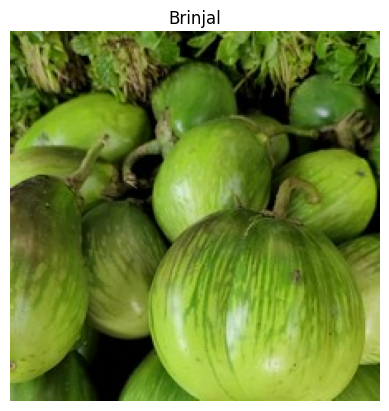

In [11]:
img = view_random_image(target_dir='Vegetable_Images/train/',
    target_class=random.choice(class_names.flatten().tolist()))

### Pre-Paring the MODEL

In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_data = tf_keras.preprocessing.image_dataset_from_directory(directory=train_dir,
                                                                 batch_size=BATCH_SIZE,
                                                                 label_mode='categorical',
                                                                 image_size=IMG_SIZE)

test_data = tf_keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                                batch_size=BATCH_SIZE,
                                                                label_mode='categorical',
                                                                image_size=IMG_SIZE,
                                                                shuffle=False)

Found 15000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.


In [13]:
train_data, test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 15), dtype=tf.float32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 15), dtype=tf.float32, name=None))>)

In [14]:
from tf_keras.layers import RandomFlip, RandomHeight, RandomRotation,RandomWidth, RandomZoom

In [15]:
data_augmentation = Sequential([
    RandomFlip('horizontal'),
    RandomHeight(0.1),
    RandomWidth(0.1),
    RandomRotation(0.1),
    RandomZoom(0.2)
    #tf_keras.layers.Rescaling(1./255)
], name='data_augmentation')

Text(0.5, 1.0, 'Augmented Image: Broccoli: (1, 211, 234, 3)')

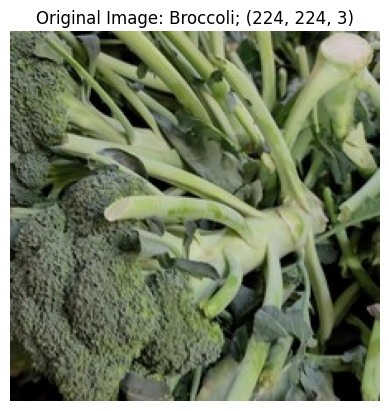

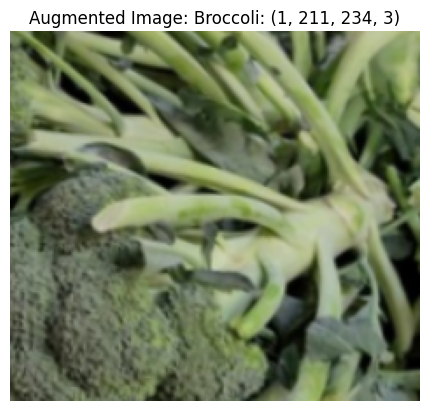

In [16]:
target_class = random.choice(train_data.class_names)
target_dir = 'Vegetable_Images/train/'+target_class
random_img = random.choice(os.listdir(target_dir))
path = target_dir +"/"+ random_img
img = mpimg.imread(path)
plt.figure()
plt.imshow(img)
plt.title(f'Original Image: {target_class}; {img.shape}')
plt.axis('off')
plt.figure()
augmented_img = data_augmentation(tf.expand_dims(img, axis=0), training=True)
plt.imshow(tf.squeeze(augmented_img)/255.)
plt.axis('off')
plt.title(f'Augmented Image: {target_class}: {augmented_img.shape}')

In [17]:
input_shape = (224, 224, 3)

In [18]:
base_model = tf_keras.applications.EfficientNetV2B0(include_top=False,weights='imagenet')
base_model.trainable=False

In [19]:
inputs = Input(shape=input_shape, name='input_layer')
x = data_augmentation(inputs, training=True)
x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
outputs = Dense(15, activation='softmax', name='output_layer')(x)

model_1 = Model(inputs, outputs)

model_1.compile(
    loss=tf_keras.losses.CategoricalCrossentropy(),
    optimizer=tf_keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

In [20]:
model_1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequent  (None, None, None, 3)     0         
 ial)                                                            
                                                                 
 efficientnetv2-b0 (Functio  (None, None, None, 1280   5919312   
 nal)                        )                                   
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                             

In [21]:
def model_checkpoint(checkpoint_dir, model_name):
    checkpoint_path = checkpoint_dir+model_name
    checkpoint = ModelCheckpoint(filepath=checkpoint_path,
                                save_weights_only=True,
                                save_best_only=True,
                                monitor='val_loss',
                                mode='min',
                                save_freq='epoch',
                                verbose=1)
    return checkpoint

In [22]:
def tensorboard_callback(dir_name, experiment_name):
    log_dir = dir_name+'/'+experiment_name+'/'+datetime.datetime.now().strftime('%Y%m%d=%H%M%S')
    tensorboard_callback = tf_keras.callbacks.TensorBoard(log_dir)
    print(f'saving tensorboard logfiles to: {log_dir}')
    return tensorboard_callback

In [23]:
early_stopping = tf_keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

In [24]:
model_1.layers

In [25]:
for layer_number, layer in enumerate(model_1.layers):
    print(f"Layer number: {layer_number} | Layer name: {layer.name} | Layer type:{layer} | Trainable? {layer.trainable}")

Layer number: 0 | Layer name: input_layer | Layer type:<tf_keras.src.engine.input_layer.InputLayer object at 0x00000263E514A540> | Trainable? True
Layer number: 1 | Layer name: data_augmentation | Layer type:<tf_keras.src.engine.sequential.Sequential object at 0x00000263DE3B7410> | Trainable? True
Layer number: 2 | Layer name: efficientnetv2-b0 | Layer type:<tf_keras.src.engine.functional.Functional object at 0x00000263E5170F50> | Trainable? False
Layer number: 3 | Layer name: global_average_pooling2d | Layer type:<tf_keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D object at 0x00000263DE3125D0> | Trainable? True
Layer number: 4 | Layer name: dense | Layer type:<tf_keras.src.layers.core.dense.Dense object at 0x00000263E3450D70> | Trainable? True
Layer number: 5 | Layer name: batch_normalization | Layer type:<tf_keras.src.layers.normalization.batch_normalization.BatchNormalization object at 0x00000263E516DA00> | Trainable? True
Layer number: 6 | Layer name: dropo

In [ ]:
history_1 = model_1.fit(train_data,
                        epochs=7,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data),
                        callbacks=[early_stopping,
                            tensorboard_callback(
                                dir_name='tensorflow_hub/02092025/1/',experiment_name='model_1'),
                            model_checkpoint(
                                checkpoint_dir='weights/02092025/checkpoint_1/', 
                                model_name='checkpoint.ckpt')]
)

saving tensorboard logfiles to: tensorflow_hub/02092025/1//model_1/20250927=130208
Epoch 1/7


472/938 [==============>...............] - ETA: 2:27 - loss: 0.7116 - accuracy: 0.7936

In [27]:
model_1.save('model_1.h5')

In [28]:
loaded_saved_model_1 = tf_keras.models.load_model(
    'model_1.keras',
    custom_objects={'data_augmentation': data_augmentation}
)

In [29]:
for layer_number, layer in enumerate(loaded_saved_model_1.layers):
    print(f"Layer number: {layer_number} | Layer name: {layer.name} | Layer type:{layer} | Trainable? {layer.trainable}")

Layer number: 0 | Layer name: input_layer | Layer type:<tf_keras.src.engine.input_layer.InputLayer object at 0x000001D39796CCE0> | Trainable? True
Layer number: 1 | Layer name: data_augmentation | Layer type:<tf_keras.src.engine.sequential.Sequential object at 0x000001D397A9E060> | Trainable? True
Layer number: 2 | Layer name: efficientnetv2-b0 | Layer type:<tf_keras.src.engine.functional.Functional object at 0x000001D397977710> | Trainable? True
Layer number: 3 | Layer name: global_average_pooling2d | Layer type:<tf_keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D object at 0x000001D38042D160> | Trainable? True
Layer number: 4 | Layer name: dense | Layer type:<tf_keras.src.layers.core.dense.Dense object at 0x000001D396DDB200> | Trainable? True
Layer number: 5 | Layer name: batch_normalization | Layer type:<tf_keras.src.layers.normalization.batch_normalization.BatchNormalization object at 0x000001D397C113D0> | Trainable? True
Layer number: 6 | Layer name: dropou

### Access the base_model layers of model_2

In [30]:
model_1_pretrained_model = loaded_saved_model_1.layers[2]
model_1_pretrained_model.name

'efficientnetv2-b0'

In [31]:
for layer_number, layer in enumerate(model_1_pretrained_model.layers):
    print(layer_number, layer.name, layer.trainable)

0 input_1 True
1 rescaling False
2 normalization False
3 stem_conv False
4 stem_bn False
5 stem_activation False
6 block1a_project_conv False
7 block1a_project_bn False
8 block1a_project_activation False
9 block2a_expand_conv False
10 block2a_expand_bn False
11 block2a_expand_activation False
12 block2a_project_conv False
13 block2a_project_bn False
14 block2b_expand_conv False
15 block2b_expand_bn False
16 block2b_expand_activation False
17 block2b_project_conv False
18 block2b_project_bn False
19 block2b_drop False
20 block2b_add False
21 block3a_expand_conv False
22 block3a_expand_bn False
23 block3a_expand_activation False
24 block3a_project_conv False
25 block3a_project_bn False
26 block3b_expand_conv False
27 block3b_expand_bn False
28 block3b_expand_activation False
29 block3b_project_conv False
30 block3b_project_bn False
31 block3b_drop False
32 block3b_add False
33 block4a_expand_conv False
34 block4a_expand_bn False
35 block4a_expand_activation False
36 block4a_dwconv2 False

In [32]:
model_1_pretrained_model.trainable=True
for layers in model_1_pretrained_model.layers[:-20]:
    layers.trainable = False

In [33]:
for layer_number, layer in enumerate(model_1_pretrained_model.layers):
    print(layer_number, layer.name, layer.trainable)

0 input_1 False
1 rescaling False
2 normalization False
3 stem_conv False
4 stem_bn False
5 stem_activation False
6 block1a_project_conv False
7 block1a_project_bn False
8 block1a_project_activation False
9 block2a_expand_conv False
10 block2a_expand_bn False
11 block2a_expand_activation False
12 block2a_project_conv False
13 block2a_project_bn False
14 block2b_expand_conv False
15 block2b_expand_bn False
16 block2b_expand_activation False
17 block2b_project_conv False
18 block2b_project_bn False
19 block2b_drop False
20 block2b_add False
21 block3a_expand_conv False
22 block3a_expand_bn False
23 block3a_expand_activation False
24 block3a_project_conv False
25 block3a_project_bn False
26 block3b_expand_conv False
27 block3b_expand_bn False
28 block3b_expand_activation False
29 block3b_project_conv False
30 block3b_project_bn False
31 block3b_drop False
32 block3b_add False
33 block4a_expand_conv False
34 block4a_expand_bn False
35 block4a_expand_activation False
36 block4a_dwconv2 Fals

In [34]:
loaded_saved_model_1.compile(
    loss=tf_keras.losses.CategoricalCrossentropy(),
    optimizer=tf_keras.optimizers.Adam(learning_rate=0.00001),
    metrics=['accuracy']
)

In [35]:
loaded_saved_model_1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequent  (None, None, None, 3)     0         
 ial)                                                            
                                                                 
 efficientnetv2-b0 (Functio  (None, None, None, 1280   5919312   
 nal)                        )                                   
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                             

In [36]:
history_1_finetune = loaded_saved_model_1.fit(train_data,
                                              epochs=14,
                                              validation_data=test_data,
                                              validation_steps=len(test_data),
                                              initial_epoch=history_1.epoch[-1],
                                              callbacks=[early_stopping,
                                                         tensorboard_callback(dir_name='tensorflow_hub/02092025/', experiment_name='loaded_saved_model_1_with_finetune_rev_1'),
                                                         model_checkpoint(checkpoint_dir='weights/02092025/checkpoint_1_finetune/', model_name='checkpoint.ckpt')
                                                        ]
)

saving tensorboard logfiles to: tensorflow_hub/02092025//loaded_saved_model_1_with_finetune_rev_1/20250420=112731
Epoch 7/14
938/938 [==============================] - ETA: 0s - loss: 0.0121 - accuracy: 0.9970
Epoch 7: val_loss improved from inf to 0.00550, saving model to weights/02092025/checkpoint_1_finetune\checkpoint.ckpt
938/938 [==============================] - 441s 457ms/step - loss: 0.0121 - accuracy: 0.9970 - val_loss: 0.0055 - val_accuracy: 0.9980
Epoch 8/14
938/938 [==============================] - ETA: 0s - loss: 0.0095 - accuracy: 0.9971
Epoch 8: val_loss did not improve from 0.00550
938/938 [==============================] - 432s 460ms/step - loss: 0.0095 - accuracy: 0.9971 - val_loss: 0.0062 - val_accuracy: 0.9977
Epoch 9/14
938/938 [==============================] - ETA: 0s - loss: 0.0096 - accuracy: 0.9975
Epoch 9: val_loss improved from 0.00550 to 0.00454, saving model to weights/02092025/checkpoint_1_finetune\checkpoint.ckpt
938/938 [==============================

In [37]:
model_2 = loaded_saved_model_1

In [38]:
loss_model_1, accuracy_model_1 = model_1.evaluate(test_data)
loss_model_2, accuracy_model_2 = model_2.evaluate(test_data)
print(f'model_1 loss:{loss_model_1}, accuracy:{accuracy_model_1}')
print(f'model_2 loss:{loss_model_2}, accuracy:{accuracy_model_2}')

188/188 [==============================] - 64s 338ms/step - loss: 0.0075 - accuracy: 0.9983
model_1 loss:0.008300346322357655, accuracy:0.9976666569709778
model_2 loss:0.007540658116340637, accuracy:0.9983333349227905


In [39]:
loaded_saved_model_1.save('model_2.keras')

In [40]:
model_2 = tf_keras.models.load_model(
    'model_2.keras',
    custom_objects={'data_augmentation': data_augmentation}
)

In [41]:
def compare_historys(original_history, new_history, initial_epoch=5):
    acc = original_history.history['accuracy']
    loss = original_history.history['loss']
    val_acc = original_history.history['val_accuracy']
    val_loss = original_history.history['val_loss']
    total_acc = acc + new_history.history['accuracy']
    total_loss = loss + new_history.history['loss']
    total_val_acc = val_acc + new_history.history['val_accuracy']
    total_val_loss = val_loss + new_history.history['val_loss']
    plt.figure(figsize=(8,8))
    plt.subplot(2,1,1)
    plt.plot(total_acc, label='Training_accuracy')
    plt.plot(total_val_acc,label='Validation_accuracy')
    plt.plot([initial_epoch-1, initial_epoch-1], plt.ylim(), label='start fine tuning')
    plt.legend()
    plt.grid()
    plt.title('training and validation accuracy')
    plt.figure(figsize=(8,8))
    plt.subplot(2,1,1)
    plt.plot(total_loss, label='Training_loss')
    plt.plot(total_val_loss, label='Validation_loss')
    plt.plot([initial_epoch-1, initial_epoch-1], plt.ylim(), label='start fine tuning')
    plt.legend()
    plt.grid()
    plt.title('training and validation loss')

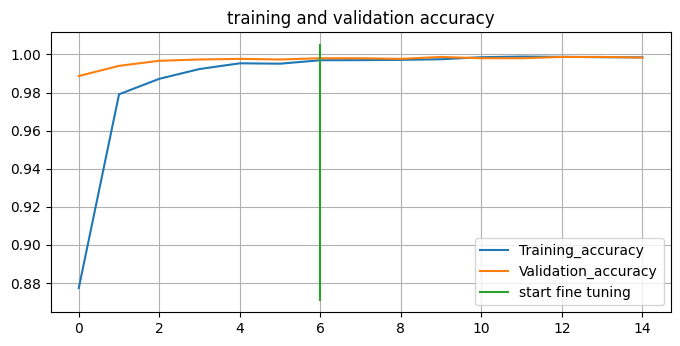

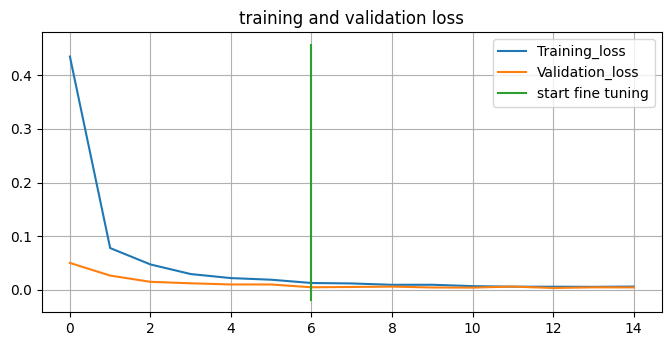

In [42]:
compare_historys(original_history=history_1,
    new_history=history_1_finetune,
    initial_epoch=7
)

In [43]:
pred_probs_1 = model_1.predict(test_data, verbose=1)
pred_probs_2 = model_2.predict(test_data, verbose=1)

188/188 [==============================] - 63s 326ms/step


In [44]:
len(pred_probs_1), len(pred_probs_2)

(3000, 3000)

In [45]:
pred_probs_1.shape, pred_probs_2.shape

((3000, 15), (3000, 15))

In [46]:
pred_probs_1[:1],pred_probs_2[:1]

(array([[9.9999344e-01, 4.9393520e-07, 6.9882482e-08, 6.1033654e-07,
         4.0183576e-07, 4.2260325e-07, 6.9459869e-09, 2.2420855e-08,
         5.6055956e-08, 1.6021428e-06, 5.9831571e-09, 5.6818117e-10,
         1.7622941e-09, 1.2569020e-08, 2.8538961e-06]], dtype=float32),
 array([[9.9999714e-01, 1.1445804e-06, 2.5699844e-08, 4.5775471e-07,
         4.3609315e-08, 7.7319818e-08, 5.2253019e-10, 3.9988095e-08,
         7.3344891e-10, 2.3770139e-07, 6.1428729e-09, 1.9609925e-09,
         1.2656822e-09, 6.7562196e-09, 8.9098882e-07]], dtype=float32))

In [47]:
print(f"Number of prediction probabilities of model_1 for sample 0:{len(pred_probs_1[0])}")
print(f"Number of prediction probabilities of model_2 for sample 0:{len(pred_probs_2[0])}")

Number of prediction probabilities of model_1 for sample 0:15
Number of prediction probabilities of model_2 for sample 0:15


In [48]:
print(f"What prediction probability of model_1 sample 0 looks like:\n{pred_probs_1[0]}")
print(f"What prediction probability of model_2 sample 0 looks like:\n{pred_probs_2[0]}")

What prediction probability of model_1 sample 0 looks like:
[9.9999344e-01 4.9393520e-07 6.9882482e-08 6.1033654e-07 4.0183576e-07
 4.2260325e-07 6.9459869e-09 2.2420855e-08 5.6055956e-08 1.6021428e-06
 5.9831571e-09 5.6818117e-10 1.7622941e-09 1.2569020e-08 2.8538961e-06]
What prediction probability of model_2 sample 0 looks like:
[9.9999714e-01 1.1445804e-06 2.5699844e-08 4.5775471e-07 4.3609315e-08
 7.7319818e-08 5.2253019e-10 3.9988095e-08 7.3344891e-10 2.3770139e-07
 6.1428729e-09 1.9609925e-09 1.2656822e-09 6.7562196e-09 8.9098882e-07]


In [50]:
print(f"The class with the highest predicted probability by the model_1 for sample 0: {pred_probs_1[0].argmax()}")
print(f"The class with the highest predicted probability by the model_2 for sample 0: {pred_probs_2[0].argmax()}")

The class with the highest predicted probability by the model_1 for sample 0: 0
The class with the highest predicted probability by the model_2 for sample 0: 0


In [51]:
y_labels = []
for images, labels in test_data.unbatch():
    y_labels.append(labels.numpy().argmax())
y_labels[:20]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [52]:
pred_classes_1 = pred_probs_1.argmax(axis=1)
pred_classes_1[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64)

In [53]:
pred_classes_2 = pred_probs_2.argmax(axis=1)
pred_classes_2[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64)

In [54]:
from sklearn.metrics import accuracy_score
sklearn_accuracy_1 = accuracy_score(y_labels, pred_classes_1)
sklearn_accuracy_2 = accuracy_score(y_labels, pred_classes_2)
sklearn_accuracy_1, sklearn_accuracy_2

(0.998, 0.9993333333333333)

In [55]:
import numpy as np
print(f"Close? {np.isclose(accuracy_model_1, sklearn_accuracy_1)} | Difference:{accuracy_model_1 - sklearn_accuracy_1}")

Close? False | Difference:-0.000333343029022215


In [56]:
import numpy as np
print(f"Close? {np.isclose(accuracy_model_2, sklearn_accuracy_2)} | Difference:{accuracy_model_2 - sklearn_accuracy_2}")

Close? False | Difference:-0.0009999984105427684


In [57]:
class_names = test_data.class_names
class_names[:5]

['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli']

In [58]:
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(15, 15),text_size=10, norm=False,title="", save_name='matrix.png', savefig=False):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    n_classes = cm.shape[0]
    fig, ax = plt.subplots(figsize=figsize)
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)
    if classes:
        labels = classes
    else:
        labels = np.arange(cm.shape[0])
        ax.set(title=title,
    xlabel="Predicted label",
            ylabel="True label",
            xticks=np.arange(n_classes),
            yticks=np.arange(n_classes),
            xticklabels=labels,
            yticklabels=labels)
    ax.xaxis.set_label_position("bottom")
    ax.xaxis.tick_bottom()
    plt.xticks(rotation=70, fontsize=text_size)
    plt.yticks(fontsize=text_size)
    threshold = (cm.max() + cm.min()) / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if norm:
            plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
                horizontalalignment="center",
                color="white" if cm[i, j] > threshold else "black",
                size=text_size)
        else:
            plt.text(j, i, f"{cm[i, j]}",
                horizontalalignment="center",
                color="white" if cm[i, j] > threshold else "black",
                size=text_size)
    if savefig:
        fig.savefig(save_name)

### Confusion Matrix

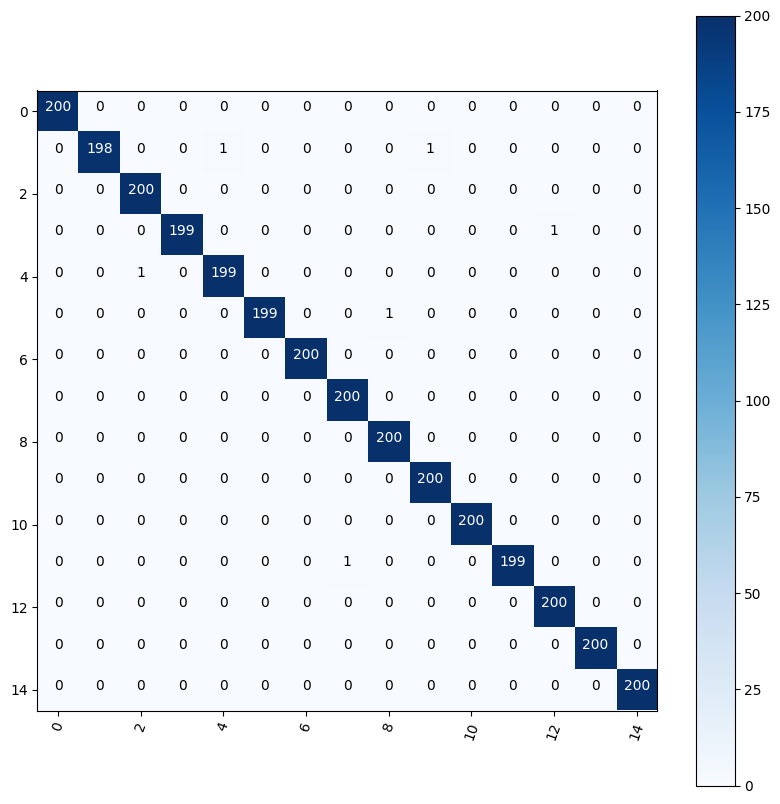

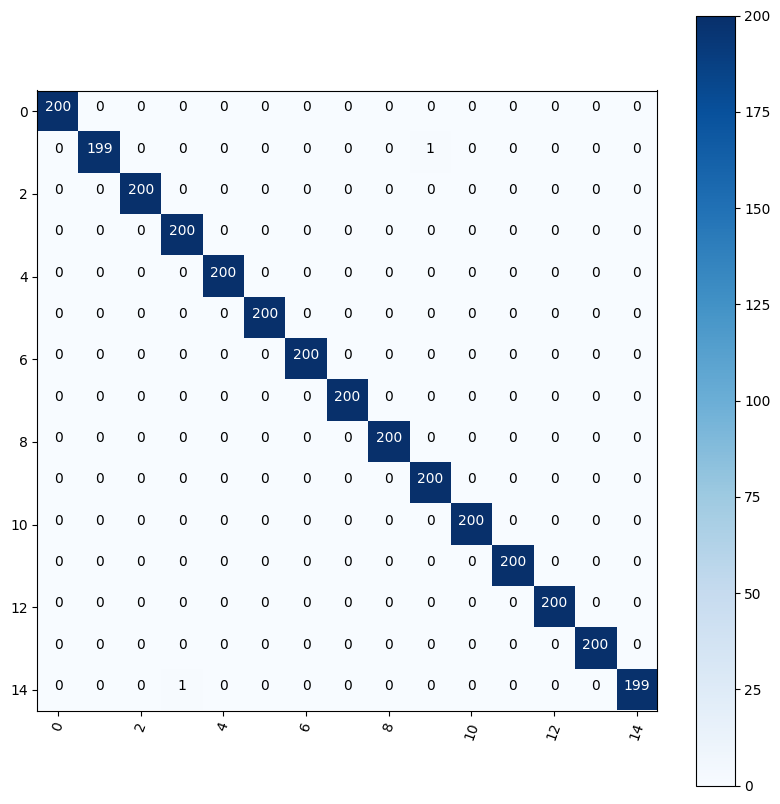

In [60]:
make_confusion_matrix(y_true=y_labels,
    y_pred=pred_classes_1,
    classes=class_names,
    figsize=(10, 10),
    text_size=10,
    title="Model_1 Confusion Matrix",
    norm=False,
    savefig=True)
make_confusion_matrix(y_true=y_labels,
    y_pred=pred_classes_2,
    classes=class_names,
    figsize=(10, 10),
    text_size=10,
    title="Model_2 Confusion Matrix",
    norm=False,
    savefig=True)

In [61]:
from sklearn.metrics import classification_report
print(classification_report(y_labels, pred_classes_1, zero_division=0))  # Default (0.0)
print(classification_report(y_labels, pred_classes_2, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      0.99      0.99       200
           2       1.00      1.00      1.00       200
           3       1.00      0.99      1.00       200
           4       0.99      0.99      0.99       200
           5       1.00      0.99      1.00       200
           6       1.00      1.00      1.00       200
           7       1.00      1.00      1.00       200
           8       1.00      1.00      1.00       200
           9       1.00      1.00      1.00       200
          10       1.00      1.00      1.00       200
          11       1.00      0.99      1.00       200
          12       1.00      1.00      1.00       200
          13       1.00      1.00      1.00       200
          14       1.00      1.00      1.00       200

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00   

In [62]:
classification_report_dict_1 = classification_report(y_labels, pred_classes_1,output_dict=True)
classification_report_dict_2 = classification_report(y_labels, pred_classes_2,output_dict=True)

In [63]:
class_f1_scores_1 = {}
for k, v in classification_report_dict_1.items():
    if k == "accuracy":
        break
    else:
        class_f1_scores_1[class_names[int(k)]] = v["f1-score"]
class_f1_scores_1

{'Bean': 1.0,
 'Bitter_Gourd': 0.9949748743718593,
 'Bottle_Gourd': 0.9975062344139651,
 'Brinjal': 0.9974937343358395,
 'Broccoli': 0.995,
 'Cabbage': 0.9974937343358395,
 'Capsicum': 1.0,
 'Carrot': 0.9975062344139651,
 'Cauliflower': 0.9975062344139651,
 'Cucumber': 0.9975062344139651,
 'Papaya': 1.0,
 'Potato': 0.9974937343358395,
 'Pumpkin': 0.9975062344139651,
 'Radish': 1.0,
 'Tomato': 1.0}

In [64]:
class_f1_scores_2 = {}
for k, v in classification_report_dict_2.items():
    if k == "accuracy":
        break
    else:
        class_f1_scores_2[class_names[int(k)]] = v["f1-score"]
class_f1_scores_2

{'Bean': 1.0,
 'Bitter_Gourd': 0.9974937343358395,
 'Bottle_Gourd': 1.0,
 'Brinjal': 0.9975062344139651,
 'Broccoli': 1.0,
 'Cabbage': 1.0,
 'Capsicum': 1.0,
 'Carrot': 1.0,
 'Cauliflower': 1.0,
 'Cucumber': 0.9975062344139651,
 'Papaya': 1.0,
 'Potato': 1.0,
 'Pumpkin': 1.0,
 'Radish': 1.0,
 'Tomato': 0.9974937343358395}

### f-score

In [65]:
f1_scores_1 = pd.DataFrame({"class_name": list(class_f1_scores_1.keys()),
                            "f1-score": list(class_f1_scores_1.values())}).sort_values("f1-score", ascending=False)
f1_scores_1.head()

,class_name,f1-score
0,Bean,1.0
6,Capsicum,1.0
10,Papaya,1.0
13,Radish,1.0
14,Tomato,1.0


In [66]:
f1_scores_2 = pd.DataFrame({"class_name": list(class_f1_scores_2.keys()),
                            "f1-score": list(class_f1_scores_2.values())}).sort_values("f1-score", ascending=False)
f1_scores_2.head()

,class_name,f1-score
0,Bean,1.0
2,Bottle_Gourd,1.0
4,Broccoli,1.0
5,Cabbage,1.0
6,Capsicum,1.0


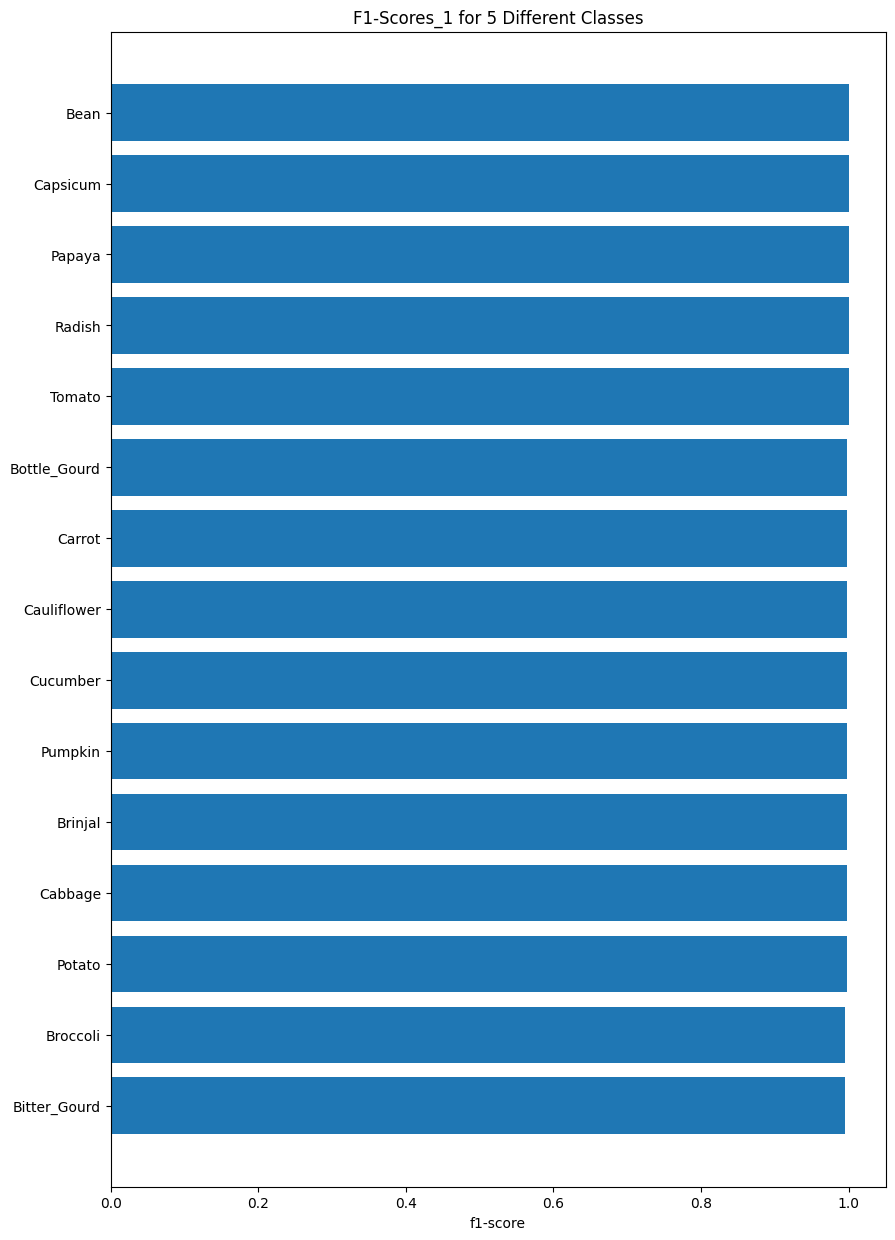

In [67]:
fig, ax = plt.subplots(figsize=(10, 15))
scores = ax.barh(range(len(f1_scores_1)), f1_scores_1["f1-score"].values)
ax.set_yticks(range(len(f1_scores_1)))
ax.set_yticklabels(list(f1_scores_1["class_name"]))
ax.set_xlabel("f1-score")
ax.set_title("F1-Scores_1 for 5 Different Classes")
ax.invert_yaxis();
def autolabel(rects):
    """
    Attach a text label above each bar displaying its height (it's value).
    """
    for rect in rects:
        width = rect.get_width()
        ax.text(1.03*width, rect.get_y() + rect.get_height()/1.5,
            f"{width:.2f}",
            ha='center', va='bottom')
    autolabel(scores)

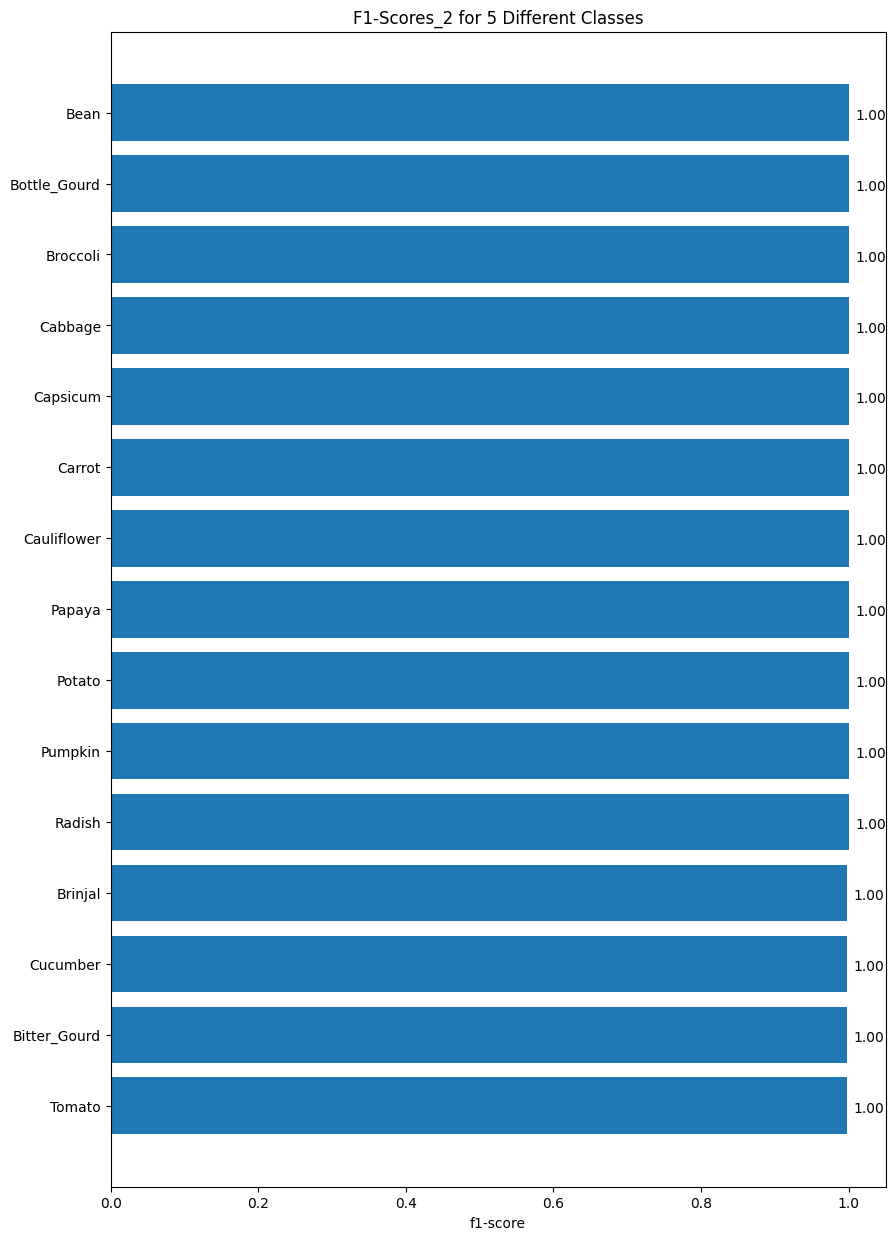

In [93]:
fig, ax = plt.subplots(figsize=(10, 15))
scores = ax.barh(range(len(f1_scores_2)), f1_scores_2["f1-score"].values)
ax.set_yticks(range(len(f1_scores_2)))
ax.set_yticklabels(list(f1_scores_2["class_name"]))
ax.set_xlabel("f1-score")
ax.set_title("F1-Scores_2 for 5 Different Classes")
ax.invert_yaxis();

def autolabel(rects):
    """
    Attach a text label above each bar displaying its height (it's value).
    """
    for rect in rects:
        width = rect.get_width()
        ax.text(1.03*width, rect.get_y() + rect.get_height()/1.5,
            f"{width:.2f}",
            ha='center', va='bottom')
        
autolabel(scores)

In [94]:
def load_and_prep_image(filename, img_shape=224, scale=True):
    
    img = tf.io.read_file(filename)
    img = tf.io.decode_image(img, channels=3)
    img = tf.image.resize(img, [img_shape, img_shape])
    if scale:
        return img/255.
    else:
        return img

In [95]:
classes = ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage',
          'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato',
          'Pumpkin', 'Radish', 'Tomato']

1/1 [==============================] - 0s 458ms/step


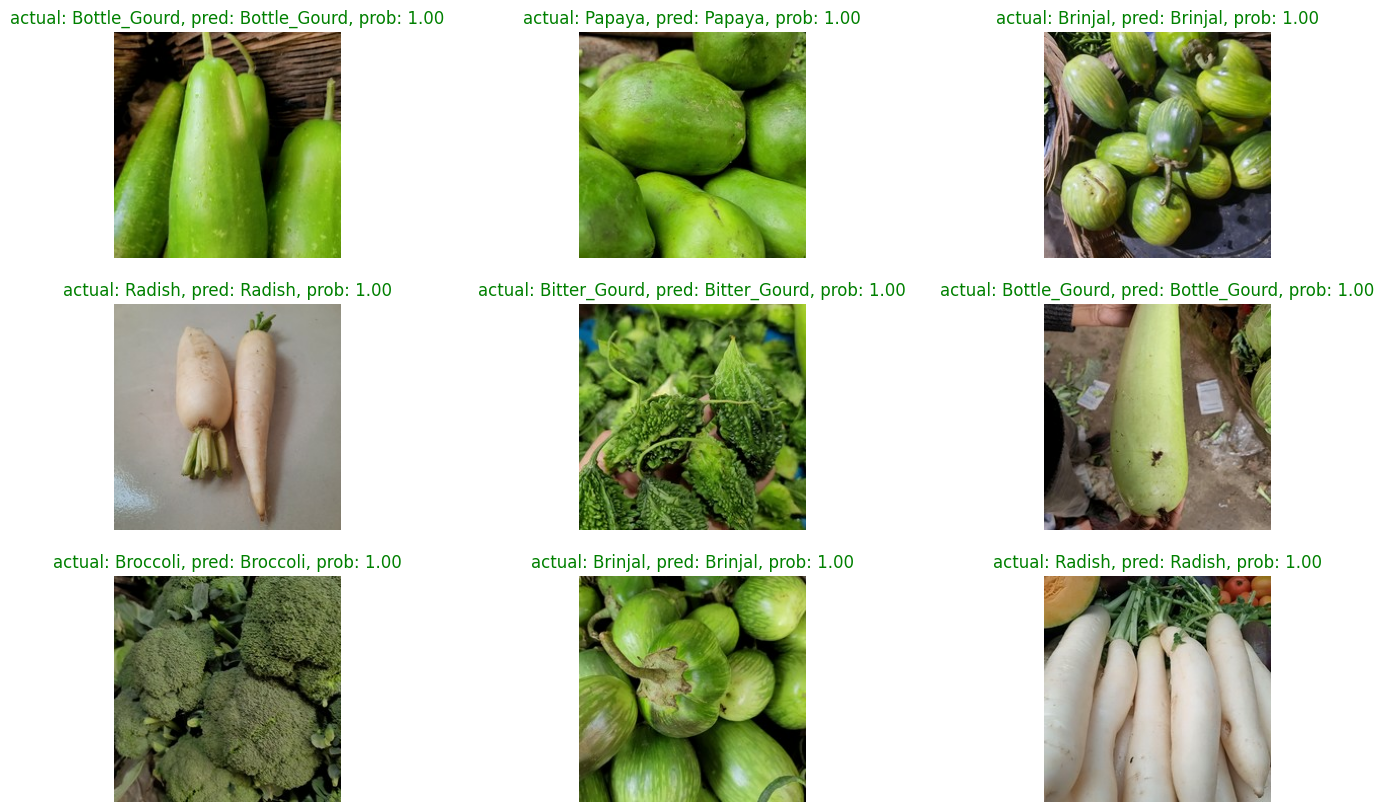

In [96]:
plt.figure(figsize=(17, 10))
n = 9;
for i in range(n):
    class_name = random.choice(class_names)
    filename = random.choice(os.listdir(test_dir + "/" + class_name))
    filepath = test_dir + class_name + "/" + filename
    img = load_and_prep_image(filepath, scale=False)
    pred_prob = model_1.predict(tf.expand_dims(img, axis=0))
    pred_class = class_names[pred_prob.argmax()]
    plt.subplot(3, 3, i+1)
    plt.imshow(img/255.)
    if class_name == pred_class:
        title_color = "g"
    else:
        title_color = "r"
    plt.title(f"actual: {class_name}, pred: {pred_class}, prob: {pred_prob.max():.2f}", c=title_color)
    plt.axis(False);

1/1 [==============================] - 0s 479ms/step


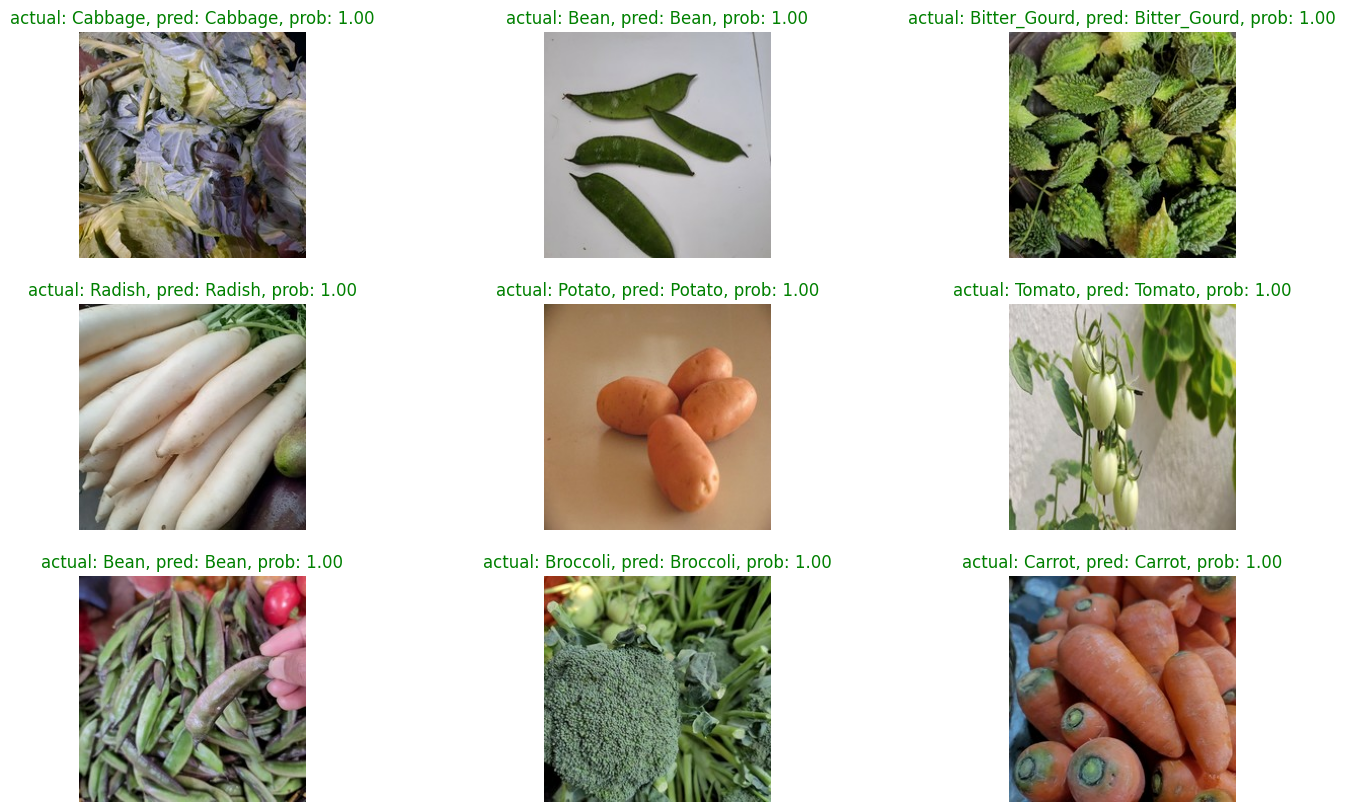

In [97]:
plt.figure(figsize=(17, 10))
n = 9;
for i in range(n):
    class_name = random.choice(class_names)
    filename = random.choice(os.listdir(test_dir + "/" + class_name))
    filepath = test_dir + class_name + "/" + filename
    
    img = load_and_prep_image(filepath, scale=False)
    pred_prob = model_2.predict(tf.expand_dims(img, axis=0))
    pred_class = class_names[pred_prob.argmax()]
    plt.subplot(3, 3, i+1)
    plt.imshow(img/255.)
    if class_name == pred_class:
        title_color = "g"
    else:
        title_color = "r"
    plt.title(f"actual: {class_name}, pred: {pred_class}, prob: {pred_prob.max():.2f}", c=title_color)
    plt.axis(False);

In [76]:
filepaths = []
for filepath in test_data.list_files("Vegetable_Images/test/*/*.jpg",
                                     shuffle=False):
    filepaths.append(filepath.numpy())
filepaths[:10]

[b'Vegetable_Images\\test\\Bean\\0001.jpg',
 b'Vegetable_Images\\test\\Bean\\0002.jpg',
 b'Vegetable_Images\\test\\Bean\\0003.jpg',
 b'Vegetable_Images\\test\\Bean\\0004.jpg',
 b'Vegetable_Images\\test\\Bean\\0005.jpg',
 b'Vegetable_Images\\test\\Bean\\0006.jpg',
 b'Vegetable_Images\\test\\Bean\\0007.jpg',
 b'Vegetable_Images\\test\\Bean\\0008.jpg',
 b'Vegetable_Images\\test\\Bean\\0009.jpg',
 b'Vegetable_Images\\test\\Bean\\0010.jpg']

In [77]:
print(f"Length of filepaths: {len(filepaths)}")
print(f"Length of y_labels: {len(y_labels)}")
print(f"Length of pred_classes_1: {len(pred_classes_1)}")
print(f"Length of pred_probs_1: {len(pred_probs_1)}")

Length of filepaths: 3000
Length of y_labels: 3000
Length of pred_classes_1: 3000
Length of pred_probs_1: 3000


In [78]:
print(f"Length of filepaths: {len(filepaths)}")
print(f"Length of y_labels: {len(y_labels)}")
print(f"Length of pred_classes_2: {len(pred_classes_2)}")
print(f"Length of pred_probs_2: {len(pred_probs_2)}")

Length of filepaths: 3000
Length of y_labels: 3000
Length of pred_classes_2: 3000
Length of pred_probs_2: 3000


In [79]:
print(filepaths[:10])
print(y_labels[:10])
print(len(y_labels))

[b'Vegetable_Images\\test\\Bean\\0001.jpg', b'Vegetable_Images\\test\\Bean\\0002.jpg', b'Vegetable_Images\\test\\Bean\\0003.jpg', b'Vegetable_Images\\test\\Bean\\0004.jpg', b'Vegetable_Images\\test\\Bean\\0005.jpg', b'Vegetable_Images\\test\\Bean\\0006.jpg', b'Vegetable_Images\\test\\Bean\\0007.jpg', b'Vegetable_Images\\test\\Bean\\0008.jpg', b'Vegetable_Images\\test\\Bean\\0009.jpg', b'Vegetable_Images\\test\\Bean\\0010.jpg']
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
3000


In [80]:
min_length = len(filepaths)

y_labels = y_labels[:min_length]
pred_classes = pred_classes_1[:min_length]
pred_probs = pred_probs_1[:min_length]

pred_df_1 = pd.DataFrame({
    "img_path": filepaths,
    "y_true": y_labels,
    "y_pred": pred_classes,
    "pred_conf": pred_probs.max(axis=1),
    "y_true_classname": [class_names[i] for i in y_labels],
    "y_pred_classname": [class_names[i] for i in pred_classes]
})

pred_df_1

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname
0,b'Vegetable_Images\\test\\Bean\\0001.jpg',0,0,0.999993,Bean,Bean
1,b'Vegetable_Images\\test\\Bean\\0002.jpg',0,0,0.999987,Bean,Bean
2,b'Vegetable_Images\\test\\Bean\\0003.jpg',0,0,0.999923,Bean,Bean
3,b'Vegetable_Images\\test\\Bean\\0004.jpg',0,0,0.999998,Bean,Bean
4,b'Vegetable_Images\\test\\Bean\\0005.jpg',0,0,0.999561,Bean,Bean
...,...,...,...,...,...,...
2995,b'Vegetable_Images\\test\\Tomato\\1196.jpg',14,14,0.999810,Tomato,Tomato
2996,b'Vegetable_Images\\test\\Tomato\\1197.jpg',14,14,0.999996,Tomato,Tomato
2997,b'Vegetable_Images\\test\\Tomato\\1198.jpg',14,14,1.000000,Tomato,Tomato
2998,b'Vegetable_Images\\test\\Tomato\\1199.jpg',14,14,0.999975,Tomato,Tomato


In [81]:
min_length = len(filepaths)

y_labels = y_labels[:min_length]
pred_classes = pred_classes_2[:min_length]
pred_probs = pred_probs_2[:min_length]

pred_df_2 = pd.DataFrame({
    "img_path": filepaths,
    "y_true": y_labels,
    "y_pred": pred_classes,
    "pred_conf": pred_probs.max(axis=1),
    "y_true_classname": [class_names[i] for i in y_labels],
    "y_pred_classname": [class_names[i] for i in pred_classes]
})

pred_df_2

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname
0,b'Vegetable_Images\\test\\Bean\\0001.jpg',0,0,0.999997,Bean,Bean
1,b'Vegetable_Images\\test\\Bean\\0002.jpg',0,0,0.999989,Bean,Bean
2,b'Vegetable_Images\\test\\Bean\\0003.jpg',0,0,0.999923,Bean,Bean
3,b'Vegetable_Images\\test\\Bean\\0004.jpg',0,0,1.000000,Bean,Bean
4,b'Vegetable_Images\\test\\Bean\\0005.jpg',0,0,0.999895,Bean,Bean
...,...,...,...,...,...,...
2995,b'Vegetable_Images\\test\\Tomato\\1196.jpg',14,14,0.999281,Tomato,Tomato
2996,b'Vegetable_Images\\test\\Tomato\\1197.jpg',14,14,0.999997,Tomato,Tomato
2997,b'Vegetable_Images\\test\\Tomato\\1198.jpg',14,14,0.999999,Tomato,Tomato
2998,b'Vegetable_Images\\test\\Tomato\\1199.jpg',14,14,0.999931,Tomato,Tomato


In [82]:
pred_df_1["pred_correct"] = pred_df_1["y_true"] == pred_df_1["y_pred"]
pred_df_1

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
0,b'Vegetable_Images\\test\\Bean\\0001.jpg',0,0,0.999993,Bean,Bean,True
1,b'Vegetable_Images\\test\\Bean\\0002.jpg',0,0,0.999987,Bean,Bean,True
2,b'Vegetable_Images\\test\\Bean\\0003.jpg',0,0,0.999923,Bean,Bean,True
3,b'Vegetable_Images\\test\\Bean\\0004.jpg',0,0,0.999998,Bean,Bean,True
4,b'Vegetable_Images\\test\\Bean\\0005.jpg',0,0,0.999561,Bean,Bean,True
...,...,...,...,...,...,...,...
2995,b'Vegetable_Images\\test\\Tomato\\1196.jpg',14,14,0.999810,Tomato,Tomato,True
2996,b'Vegetable_Images\\test\\Tomato\\1197.jpg',14,14,0.999996,Tomato,Tomato,True
2997,b'Vegetable_Images\\test\\Tomato\\1198.jpg',14,14,1.000000,Tomato,Tomato,True
2998,b'Vegetable_Images\\test\\Tomato\\1199.jpg',14,14,0.999975,Tomato,Tomato,True


In [83]:
pred_df_2["pred_correct"] = pred_df_2["y_true"] == pred_df_2["y_pred"]
pred_df_2

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
0,b'Vegetable_Images\\test\\Bean\\0001.jpg',0,0,0.999997,Bean,Bean,True
1,b'Vegetable_Images\\test\\Bean\\0002.jpg',0,0,0.999989,Bean,Bean,True
2,b'Vegetable_Images\\test\\Bean\\0003.jpg',0,0,0.999923,Bean,Bean,True
3,b'Vegetable_Images\\test\\Bean\\0004.jpg',0,0,1.000000,Bean,Bean,True
4,b'Vegetable_Images\\test\\Bean\\0005.jpg',0,0,0.999895,Bean,Bean,True
...,...,...,...,...,...,...,...
2995,b'Vegetable_Images\\test\\Tomato\\1196.jpg',14,14,0.999281,Tomato,Tomato,True
2996,b'Vegetable_Images\\test\\Tomato\\1197.jpg',14,14,0.999997,Tomato,Tomato,True
2997,b'Vegetable_Images\\test\\Tomato\\1198.jpg',14,14,0.999999,Tomato,Tomato,True
2998,b'Vegetable_Images\\test\\Tomato\\1199.jpg',14,14,0.999931,Tomato,Tomato,True


### Correct Pred

In [84]:
correct_1 = pred_df_1[pred_df_1["pred_correct"] == True].sort_values("pred_conf", ascending=True)[:]
correct_1

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
2033,b'Vegetable_Images\\test\\Papaya\\1231.jpg',10,10,0.481966,Papaya,Papaya,True
2923,b'Vegetable_Images\\test\\Tomato\\1124.jpg',14,14,0.496545,Tomato,Tomato,True
2167,b'Vegetable_Images\\test\\Papaya\\1368.jpg',10,10,0.670325,Papaya,Papaya,True
609,b'Vegetable_Images\\test\\Brinjal\\1002.jpg',3,3,0.703943,Brinjal,Brinjal,True
1836,b'Vegetable_Images\\test\\Cucumber\\1037.jpg',9,9,0.717603,Cucumber,Cucumber,True
...,...,...,...,...,...,...,...
2802,b'Vegetable_Images\\test\\Tomato\\1003.jpg',14,14,1.000000,Tomato,Tomato,True
2858,b'Vegetable_Images\\test\\Tomato\\1059.jpg',14,14,1.000000,Tomato,Tomato,True
1423,b'Vegetable_Images\\test\\Carrot\\1024.jpg',7,7,1.000000,Carrot,Carrot,True
2845,b'Vegetable_Images\\test\\Tomato\\1046.jpg',14,14,1.000000,Tomato,Tomato,True


In [85]:
correct_2 = pred_df_2[pred_df_2["pred_correct"] == True].sort_values("pred_conf", ascending=True)[:]
correct_2

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
1836,b'Vegetable_Images\\test\\Cucumber\\1037.jpg',9,9,0.468294,Cucumber,Cucumber,True
844,b'Vegetable_Images\\test\\Broccoli\\1045.jpg',4,4,0.491566,Broccoli,Broccoli,True
1916,b'Vegetable_Images\\test\\Cucumber\\1117.jpg',9,9,0.521909,Cucumber,Cucumber,True
1104,b'Vegetable_Images\\test\\Cabbage\\1101.jpg',5,5,0.569464,Cabbage,Cabbage,True
1949,b'Vegetable_Images\\test\\Cucumber\\1150.jpg',9,9,0.720903,Cucumber,Cucumber,True
...,...,...,...,...,...,...,...
2827,b'Vegetable_Images\\test\\Tomato\\1028.jpg',14,14,1.000000,Tomato,Tomato,True
2441,b'Vegetable_Images\\test\\Pumpkin\\1042.jpg',12,12,1.000000,Pumpkin,Pumpkin,True
2437,b'Vegetable_Images\\test\\Pumpkin\\1038.jpg',12,12,1.000000,Pumpkin,Pumpkin,True
2865,b'Vegetable_Images\\test\\Tomato\\1066.jpg',14,14,1.000000,Tomato,Tomato,True


### Wrong Pred

In [86]:
wrong_1 = pred_df_1[pred_df_1["pred_correct"] == False].sort_values("pred_conf", ascending=False)[:]
wrong_1

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
1104,b'Vegetable_Images\\test\\Cabbage\\1101.jpg',5,8,0.905188,Cabbage,Cauliflower,False
289,b'Vegetable_Images\\test\\Bitter_Gourd\\1290.jpg',1,4,0.662615,Bitter_Gourd,Broccoli,False
2309,b'Vegetable_Images\\test\\Potato\\1112.jpg',11,7,0.643104,Potato,Carrot,False
844,b'Vegetable_Images\\test\\Broccoli\\1045.jpg',4,2,0.631034,Broccoli,Bottle_Gourd,False
630,b'Vegetable_Images\\test\\Brinjal\\1023.jpg',3,12,0.613114,Brinjal,Pumpkin,False
325,b'Vegetable_Images\\test\\Bitter_Gourd\\1326.jpg',1,9,0.541961,Bitter_Gourd,Cucumber,False


In [87]:
wrong_2 = pred_df_2[pred_df_2["pred_correct"] == False].sort_values("pred_conf", ascending=False)[:]
wrong_2

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
2923,b'Vegetable_Images\\test\\Tomato\\1124.jpg',14,3,0.908386,Tomato,Brinjal,False
325,b'Vegetable_Images\\test\\Bitter_Gourd\\1326.jpg',1,9,0.873824,Bitter_Gourd,Cucumber,False


In [88]:
print(f'out of {len(y_labels)} samples\nmodel_1: wrong:{len(wrong_1)}, correct:{len(correct_1)}\nmodel_2: wrong:{len(wrong_2)}, correct:{len(correct_2)}')

out of 3000 samples
model_1: wrong:6, correct:2994
model_2: wrong:2, correct:2998


# 0.1 Model 2 Test Deployment

In [90]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import tf_keras as tf_keras
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
import io

IMG_SIZE = 224 # Image size for processing
classes = ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage',
          'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato',
          'Pumpkin', 'Radish', 'Tomato']
model_path = 'model_2.keras'

# Load the model
def load_model():
    print("Loading model...") 
    try:
        model = tf_keras.models.load_model(model_path,custom_objects={'data_augmentation': None})
        print("Model loaded successfully!")
        return model
    except Exception as e:
        print(f"Error loading model: {e}")
        return None

model = load_model()

# Image preprocessing function
def load_and_prep_image(image, img_shape=224, scale=True):
    """Loads an image, turns it into a tensor and reshapes it."""
    img = tf.image.resize(image, [img_shape, img_shape])
    return img / 255. if scale else img # Normalize pixel values

# Output Widget for Logs and Display
output = widgets.Output()

# Function to process uploaded image and make predictions
def predict_uploaded_image(change):
    with output:
        clear_output(wait=True)
        if model is None:
            print("Model failed to load. Please check the file path.")
            return
            
        uploaded_file = change['new']
        if not uploaded_file:
            print("No file uploaded. Please upload an image.")
            return
            
        try:
            # Read and process image
            file_content = uploaded_file[0].content
            image = Image.open(io.BytesIO(file_content)).convert("RGB")
            img_array = np.array(image)
          
            img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
            img_tensor = load_and_prep_image(img_tensor, scale=False)
            img_array = tf.expand_dims(img_tensor, axis=0) # Add batch dimension

            # Predict
            pred_prob = model.predict(img_array)
            pred_class = classes[np.argmax(pred_prob)]

            # Display image
            plt.figure(figsize=(7, 7))
            plt.imshow(image)
            plt.title(f"Predicted: {pred_class}, Prob: {np.max(pred_prob):.2f}", color="blue")
            plt.axis(False)
            plt.show()

        except Exception as e:
            print(f"Error during prediction: {e}")

upload = widgets.FileUpload(accept='image/*', multiple=False)
upload.observe(predict_uploaded_image, names='value')

display(upload, output)

Loading model...
Model loaded successfully!


FileUpload(value=(), accept='image/*', description='Upload')

Output()